# ADANIPORTS Time Series Analysis
This notebook demonstrates the analyzer package. I analyze the historical price data of ADANIPORTS to identify trends, seasonality, and volatility.

In [12]:
# Import the package modules
from analyzer.preprocessor import DataPreprocessor
from analyzer.analyzer import TimeSeriesAnalyzer
from analyzer.visualizer import TimeSeriesVisualizer
import pandas as pd

# Load the data
df = pd.read_csv("../data/ADANIPORTS.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.0,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
1,2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.0,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2,2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.0,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
3,2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.0,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
4,2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.0,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741


In [13]:
# 1. Cleaning and Preprocessing
prep = DataPreprocessor(df)
df_clean = prep.process_data()
df_clean = prep.handle_outliers()
print("Data cleaned and gaps filled via interpolation.")

Data cleaned and gaps filled via interpolation.


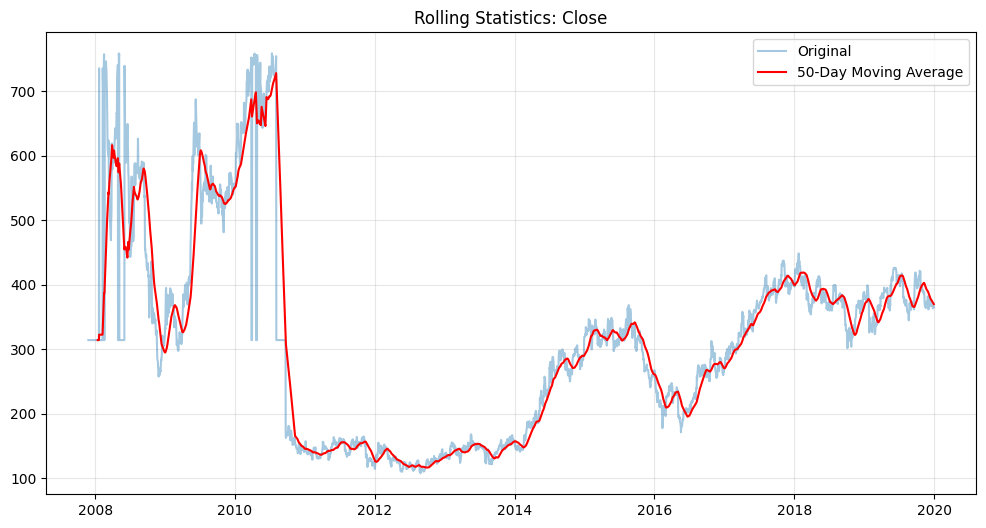

In [14]:
# 2. Visualizing Trends
viz = TimeSeriesVisualizer(df_clean)
viz.plot_rolling_stats(window=50) # 50-day moving average

In [15]:
# 3. Statistical Analysis
analysis = TimeSeriesAnalyzer(df_clean)
print(f"Is the series stationary? {analysis.adf_test()['is_stationary']}")
vol = analysis.get_volatility_stats()
print(f"The Annual Volatility is {vol['Annual Volatility']:.2%}")

Is the series stationary? False
The Annual Volatility is 99.25%


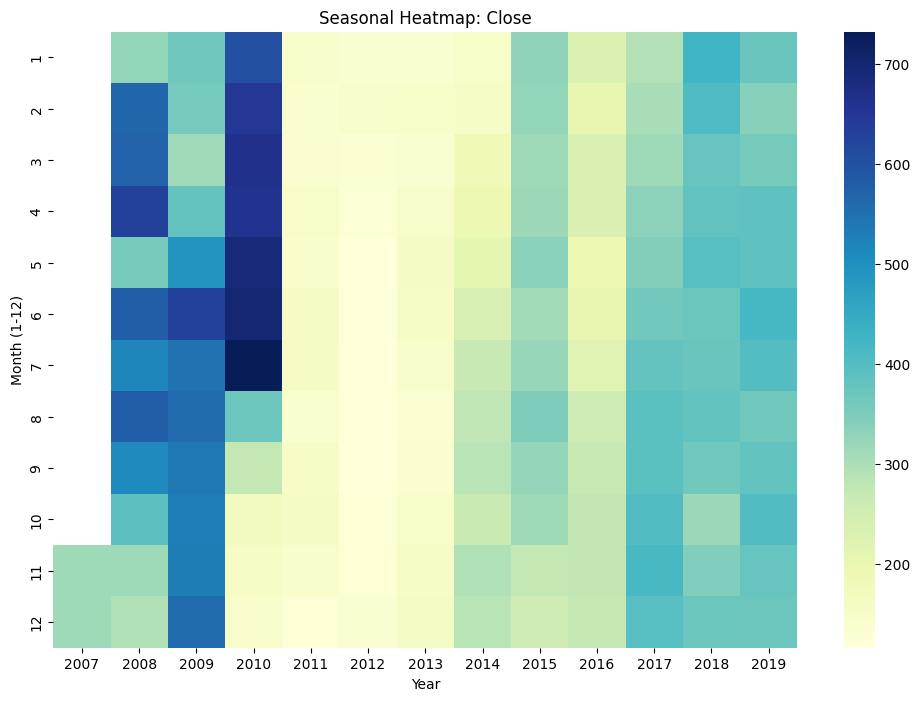

In [16]:
# 4. Seasonality
viz.plot_seasonal_heatmap()